In [1]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- Path setup ---
# Since notebook is inside 'notebooks' folder, 
# we go one level up to reach the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

csv_path = os.path.join(project_root, 'cookie_cats.csv')
db_path = os.path.join(project_root, 'data', 'cookie_cats.db')

print("Project root:", project_root)
print("CSV path:", csv_path)
print("DB path:", db_path)
print("CSV exists:", os.path.exists(csv_path))

Project root: C:\Users\R D\AB_Test_FrameWork
CSV path: C:\Users\R D\AB_Test_FrameWork\cookie_cats.csv
DB path: C:\Users\R D\AB_Test_FrameWork\data\cookie_cats.db
CSV exists: True


In [2]:
# --- Load CSV ---
df = pd.read_csv(csv_path)

# --- Minimal sanity check ---
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (90189, 5)

Column names: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']

Dtypes:
 userid            int64
version             str
sum_gamerounds    int64
retention_1        bool
retention_7        bool
dtype: object

First 5 rows:


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
# --- Create SQLite connection ---
conn = sqlite3.connect(db_path)

# --- Push DataFrame into SQLite as a table ---
df.to_sql('cookie_cats', conn, if_exists='replace', index=False)

# --- Confirm it worked ---
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM cookie_cats")
row_count = cursor.fetchone()[0]

print("Database created at:", db_path)
print("Table 'cookie_cats' row count:", row_count)
print("DB file exists:", os.path.exists(db_path))

Database created at: C:\Users\R D\AB_Test_FrameWork\data\cookie_cats.db
Table 'cookie_cats' row count: 90189
DB file exists: True


In [4]:
# --- Query 1: Total row count ---
query_row_count = "SELECT COUNT(*) AS total_rows FROM cookie_cats"

# --- Query 2: Duplicate userid check ---
query_duplicates = """
SELECT 
    COUNT(*) AS total_rows,
    COUNT(DISTINCT userid) AS unique_users,
    COUNT(*) - COUNT(DISTINCT userid) AS duplicate_count
FROM cookie_cats
"""

# --- Run and display ---
print("=== Row Count ===")
print(pd.read_sql_query(query_row_count, conn))

print("\n=== Duplicate User Check ===")
print(pd.read_sql_query(query_duplicates, conn))

=== Row Count ===
   total_rows
0       90189

=== Duplicate User Check ===
   total_rows  unique_users  duplicate_count
0       90189         90189                0


In [5]:
# --- Query: Null count per column ---
query_nulls = """
SELECT
    COUNT(*) - COUNT(userid)            AS userid_nulls,
    COUNT(*) - COUNT(version)           AS version_nulls,
    COUNT(*) - COUNT(sum_gamerounds)    AS sum_gamerounds_nulls,
    COUNT(*) - COUNT(retention_1)       AS retention_1_nulls,
    COUNT(*) - COUNT(retention_7)       AS retention_7_nulls
FROM cookie_cats
"""

print("=== Null Check Per Column ===")
print(pd.read_sql_query(query_nulls, conn))

=== Null Check Per Column ===
   userid_nulls  version_nulls  sum_gamerounds_nulls  retention_1_nulls  \
0             0              0                     0                  0   

   retention_7_nulls  
0                  0  


In [6]:
# --- Query: Group sizes and percentage split ---
query_groups = """
SELECT
    version,
    COUNT(*) AS player_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM cookie_cats), 2) AS percentage
FROM cookie_cats
GROUP BY version
ORDER BY version
"""

print("=== Group Size and Balance Check ===")
print(pd.read_sql_query(query_groups, conn))

=== Group Size and Balance Check ===
   version  player_count  percentage
0  gate_30         44700       49.56
1  gate_40         45489       50.44


In [7]:
# --- Query: Aggregate stats per group ---
query_agg = """
SELECT
    version,
    COUNT(*)                                    AS player_count,
    ROUND(AVG(sum_gamerounds), 2)               AS avg_gamerounds,
    ROUND(AVG(CAST(retention_1 AS FLOAT)), 4)   AS retention_1_rate,
    ROUND(AVG(CAST(retention_7 AS FLOAT)), 4)   AS retention_7_rate
FROM cookie_cats
GROUP BY version
ORDER BY version
"""

print("=== Aggregate Stats Per Group ===")
print(pd.read_sql_query(query_agg, conn))

=== Aggregate Stats Per Group ===
   version  player_count  avg_gamerounds  retention_1_rate  retention_7_rate
0  gate_30         44700           52.46            0.4482            0.1902
1  gate_40         45489           51.30            0.4423            0.1820


In [8]:
# --- Pull sum_gamerounds into pandas ---
query_rounds = "SELECT userid, version, sum_gamerounds FROM cookie_cats ORDER BY sum_gamerounds DESC"
df_rounds = pd.read_sql_query(query_rounds, conn)

# --- Top 10 highest players ---
print("=== Top 10 Players by Game Rounds ===")
print(df_rounds.head(10))

# --- Quantify the outlier ---
top_value    = df_rounds['sum_gamerounds'].iloc[0]
p99          = df_rounds['sum_gamerounds'].quantile(0.99)
p95          = df_rounds['sum_gamerounds'].quantile(0.95)
mean_val     = df_rounds['sum_gamerounds'].mean()
median_val   = df_rounds['sum_gamerounds'].median()

print("\n=== Outlier Quantification ===")
print(f"Highest value       : {top_value:,}")
print(f"99th percentile     : {p99:,.1f}")
print(f"95th percentile     : {p95:,.1f}")
print(f"Mean                : {mean_val:,.2f}")
print(f"Median              : {median_val:,.1f}")
print(f"\nTop value is {top_value / p99:.1f}x the 99th percentile")
print(f"Top value is {top_value / mean_val:.1f}x the mean")
print(f"Top value is {top_value / median_val:.1f}x the median")

=== Top 10 Players by Game Rounds ===
    userid  version  sum_gamerounds
0  6390605  gate_30           49854
1   871500  gate_30            2961
2  3271615  gate_40            2640
3  4832608  gate_30            2438
4  5346171  gate_40            2294
5  5133952  gate_30            2251
6  9640085  gate_30            2156
7  4090246  gate_40            2124
8  9791599  gate_40            2063
9   725080  gate_40            2015

=== Outlier Quantification ===
Highest value       : 49,854
99th percentile     : 493.0
95th percentile     : 221.0
Mean                : 51.87
Median              : 16.0

Top value is 101.1x the 99th percentile
Top value is 961.1x the mean
Top value is 3115.9x the median


In [9]:
# --- Document the decision ---
print("""
=== OUTLIER HANDLING DECISION ===

Player userid 6390605 played 49,854 rounds.
The next highest player played 2,961 rounds.
This single player is 101x above the 99th percentile.

Decision: REMOVE this single row.

Reasoning:
- The gap between rank 1 and rank 2 is 16.8x — not a gradual tail
- 49,854 rounds implies ~35 days of non-stop playing if each round 
  takes 1 minute — not humanly possible in a 7-day observation window
- Almost certainly a bot, a test account, or a data logging error
- Keeping it would distort the mean, inflate variance, and 
  misrepresent typical player behavior
- Capping at 99th percentile (493) is an alternative but removal 
  is cleaner given this is a single isolated case
""")

# --- Remove the outlier ---
df_cleaned = df[df['sum_gamerounds'] != 49854].copy()

# --- Confirm removal ---
print(f"Original row count : {len(df):,}")
print(f"Cleaned row count  : {len(df_cleaned):,}")
print(f"Rows removed       : {len(df) - len(df_cleaned)}")

# --- Confirm new max ---
print(f"\nNew maximum sum_gamerounds : {df_cleaned['sum_gamerounds'].max():,}")
print(f"Mean before cleaning       : {df['sum_gamerounds'].mean():.2f}")
print(f"Mean after cleaning        : {df_cleaned['sum_gamerounds'].mean():.2f}")
print(f"Median before cleaning     : {df['sum_gamerounds'].median():.1f}")
print(f"Median after cleaning      : {df_cleaned['sum_gamerounds'].median():.1f}")


=== OUTLIER HANDLING DECISION ===

Player userid 6390605 played 49,854 rounds.
The next highest player played 2,961 rounds.
This single player is 101x above the 99th percentile.

Decision: REMOVE this single row.

Reasoning:
- The gap between rank 1 and rank 2 is 16.8x — not a gradual tail
- 49,854 rounds implies ~35 days of non-stop playing if each round 
  takes 1 minute — not humanly possible in a 7-day observation window
- Almost certainly a bot, a test account, or a data logging error
- Keeping it would distort the mean, inflate variance, and 
  misrepresent typical player behavior
- Capping at 99th percentile (493) is an alternative but removal 
  is cleaner given this is a single isolated case

Original row count : 90,189
Cleaned row count  : 90,188
Rows removed       : 1

New maximum sum_gamerounds : 2,961
Mean before cleaning       : 51.87
Mean after cleaning        : 51.32
Median before cleaning     : 16.0
Median after cleaning      : 16.0


In [10]:
# --- Document the decision ---
print("""
=== OUTLIER HANDLING DECISION ===

Player userid 6390605 played 49,854 rounds.
The next highest player played 2,961 rounds.
This single player is 101x above the 99th percentile.

Decision: REMOVE this single row.

Reasoning:
- The gap between rank 1 and rank 2 is 16.8x — not a gradual tail
- 49,854 rounds implies ~35 days of non-stop playing if each round 
  takes 1 minute — not humanly possible in a 7-day observation window
- Almost certainly a bot, a test account, or a data logging error
- Keeping it would distort the mean, inflate variance, and 
  misrepresent typical player behavior
- Capping at 99th percentile (493) is an alternative but removal 
  is cleaner given this is a single isolated case
""")

# --- Remove the outlier ---
df_cleaned = df[df['sum_gamerounds'] != 49854].copy()

# --- Confirm removal ---
print(f"Original row count : {len(df):,}")
print(f"Cleaned row count  : {len(df_cleaned):,}")
print(f"Rows removed       : {len(df) - len(df_cleaned)}")

# --- Confirm new max ---
print(f"\nNew maximum sum_gamerounds : {df_cleaned['sum_gamerounds'].max():,}")
print(f"Mean before cleaning       : {df['sum_gamerounds'].mean():.2f}")
print(f"Mean after cleaning        : {df_cleaned['sum_gamerounds'].mean():.2f}")
print(f"Median before cleaning     : {df['sum_gamerounds'].median():.1f}")
print(f"Median after cleaning      : {df_cleaned['sum_gamerounds'].median():.1f}")


=== OUTLIER HANDLING DECISION ===

Player userid 6390605 played 49,854 rounds.
The next highest player played 2,961 rounds.
This single player is 101x above the 99th percentile.

Decision: REMOVE this single row.

Reasoning:
- The gap between rank 1 and rank 2 is 16.8x — not a gradual tail
- 49,854 rounds implies ~35 days of non-stop playing if each round 
  takes 1 minute — not humanly possible in a 7-day observation window
- Almost certainly a bot, a test account, or a data logging error
- Keeping it would distort the mean, inflate variance, and 
  misrepresent typical player behavior
- Capping at 99th percentile (493) is an alternative but removal 
  is cleaner given this is a single isolated case

Original row count : 90,189
Cleaned row count  : 90,188
Rows removed       : 1

New maximum sum_gamerounds : 2,961
Mean before cleaning       : 51.87
Mean after cleaning        : 51.32
Median before cleaning     : 16.0
Median after cleaning      : 16.0


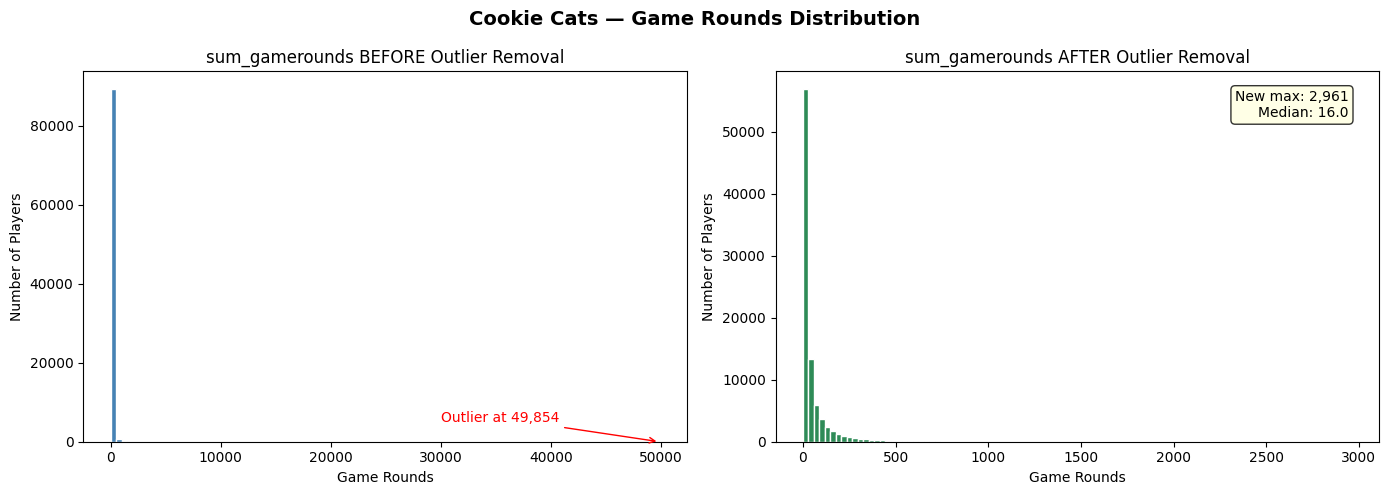

Histogram saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Before ---
axes[0].hist(df['sum_gamerounds'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('sum_gamerounds BEFORE Outlier Removal', fontsize=12)
axes[0].set_xlabel('Game Rounds')
axes[0].set_ylabel('Number of Players')
axes[0].annotate(f'Outlier at 49,854', 
                 xy=(49854, 1), 
                 xytext=(30000, 5000),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=10)

# --- After ---
axes[1].hist(df_cleaned['sum_gamerounds'], bins=100, color='seagreen', edgecolor='white')
axes[1].set_title('sum_gamerounds AFTER Outlier Removal', fontsize=12)
axes[1].set_xlabel('Game Rounds')
axes[1].set_ylabel('Number of Players')
axes[1].annotate(f'New max: 2,961\nMedian: 16.0', 
                 xy=(0.95, 0.95), 
                 xytext=(0.95, 0.95),
                 xycoords='axes fraction',
                 textcoords='axes fraction',
                 ha='right', va='top',
                 fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Cookie Cats — Game Rounds Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'data', 'histogram_gamerounds.png'), dpi=150)
plt.show()
print("Histogram saved.")

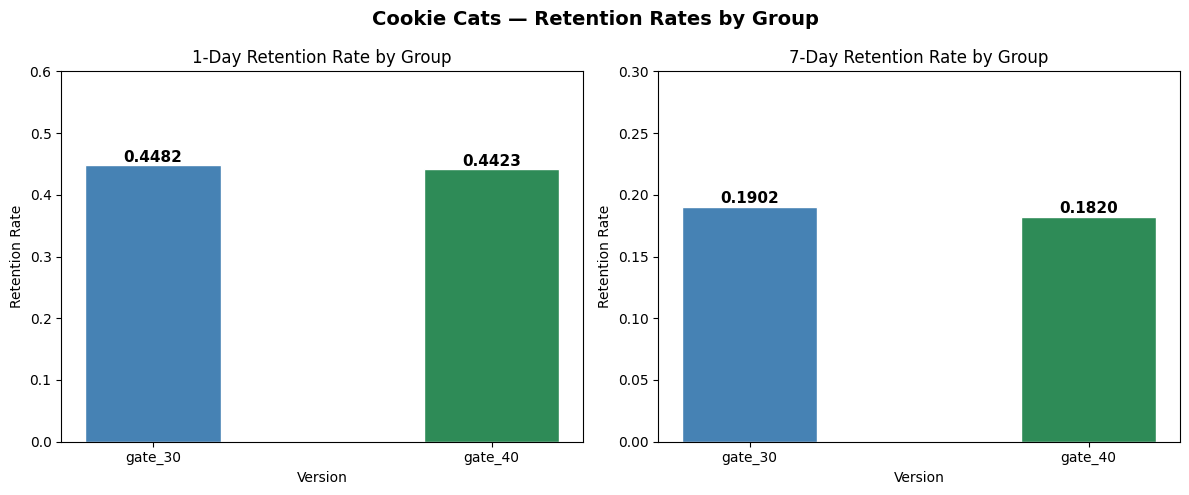

Retention chart saved.

Retention rates summary:
   version  retention_1  retention_7
0  gate_30     0.448198     0.190183
1  gate_40     0.442283     0.182000


In [12]:
# --- Calculate retention rates per group ---
retention = df_cleaned.groupby('version')[['retention_1', 'retention_7']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['steelblue', 'seagreen']

# --- Retention 1 ---
axes[0].bar(retention['version'], retention['retention_1'], color=colors, edgecolor='white', width=0.4)
axes[0].set_title('1-Day Retention Rate by Group', fontsize=12)
axes[0].set_xlabel('Version')
axes[0].set_ylabel('Retention Rate')
axes[0].set_ylim(0, 0.6)
for i, val in enumerate(retention['retention_1']):
    axes[0].text(i, val + 0.005, f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# --- Retention 7 ---
axes[1].bar(retention['version'], retention['retention_7'], color=colors, edgecolor='white', width=0.4)
axes[1].set_title('7-Day Retention Rate by Group', fontsize=12)
axes[1].set_xlabel('Version')
axes[1].set_ylabel('Retention Rate')
axes[1].set_ylim(0, 0.3)
for i, val in enumerate(retention['retention_7']):
    axes[1].text(i, val + 0.003, f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Cookie Cats — Retention Rates by Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'data', 'retention_rates_by_group.png'), dpi=150)
plt.show()
print("Retention chart saved.")
print("\nRetention rates summary:")
print(retention)

In [13]:
# --- Save cleaned dataset ---
cleaned_path = os.path.join(project_root, 'data', 'cookie_cats_cleaned.csv')
df_cleaned.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved to:", cleaned_path)
print("Shape:", df_cleaned.shape)
print("\nFinal column dtypes:")
print(df_cleaned.dtypes)
print("\nSample of cleaned data:")
df_cleaned.head()

Cleaned dataset saved to: C:\Users\R D\AB_Test_FrameWork\data\cookie_cats_cleaned.csv
Shape: (90188, 5)

Final column dtypes:
userid            int64
version             str
sum_gamerounds    int64
retention_1        bool
retention_7        bool
dtype: object

Sample of cleaned data:


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [19]:
# --- Save summary to file with utf-8 encoding ---
summary_path = os.path.join(project_root, 'data', 'phase1_data_quality_report.txt')
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary)

print("Report saved to:", summary_path)

Report saved to: C:\Users\R D\AB_Test_FrameWork\data\phase1_data_quality_report.txt


In [20]:
# --- Save all SQL queries used in Phase 1 to the sql folder ---

sql_queries = """
-- ============================================================
-- Cookie Cats A/B Test — SQL Data Quality Queries
-- Phase 1: Data Understanding & Cleaning
-- ============================================================

-- Query 1: Total row count
SELECT COUNT(*) AS total_rows 
FROM cookie_cats;

-- ────────────────────────────────────────────────────────────

-- Query 2: Duplicate userid check
SELECT 
    COUNT(*) AS total_rows,
    COUNT(DISTINCT userid) AS unique_users,
    COUNT(*) - COUNT(DISTINCT userid) AS duplicate_count
FROM cookie_cats;

-- ────────────────────────────────────────────────────────────

-- Query 3: Null check per column
SELECT
    COUNT(*) - COUNT(userid)            AS userid_nulls,
    COUNT(*) - COUNT(version)           AS version_nulls,
    COUNT(*) - COUNT(sum_gamerounds)    AS sum_gamerounds_nulls,
    COUNT(*) - COUNT(retention_1)       AS retention_1_nulls,
    COUNT(*) - COUNT(retention_7)       AS retention_7_nulls
FROM cookie_cats;

-- ────────────────────────────────────────────────────────────

-- Query 4: Group sizes and balance
SELECT
    version,
    COUNT(*) AS player_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM cookie_cats), 2) AS percentage
FROM cookie_cats
GROUP BY version
ORDER BY version;

-- ────────────────────────────────────────────────────────────

-- Query 5: Aggregate stats per group
SELECT
    version,
    COUNT(*)                                    AS player_count,
    ROUND(AVG(sum_gamerounds), 2)               AS avg_gamerounds,
    ROUND(AVG(CAST(retention_1 AS FLOAT)), 4)   AS retention_1_rate,
    ROUND(AVG(CAST(retention_7 AS FLOAT)), 4)   AS retention_7_rate
FROM cookie_cats
GROUP BY version
ORDER BY version;

-- ────────────────────────────────────────────────────────────

-- Query 6: Top 10 players by game rounds (outlier investigation)
SELECT 
    userid, 
    version, 
    sum_gamerounds 
FROM cookie_cats 
ORDER BY sum_gamerounds DESC
LIMIT 10;

-- ────────────────────────────────────────────────────────────

-- Query 7: Outlier quantification
SELECT
    MAX(sum_gamerounds)                                    AS max_value,
    ROUND(AVG(sum_gamerounds), 2)                          AS mean_value,
    COUNT(*) / 2                                           AS median_approx_n,
    (SELECT sum_gamerounds 
     FROM cookie_cats 
     ORDER BY sum_gamerounds 
     LIMIT 1 
     OFFSET (SELECT COUNT(*)/2 FROM cookie_cats))          AS median_approx
FROM cookie_cats;
"""

# --- Save to sql folder ---
sql_path = os.path.join(project_root, 'sql', 'phase1_data_quality_checks.sql')
with open(sql_path, 'w', encoding='utf-8') as f:
    f.write(sql_queries)

print(f"SQL queries saved to: {sql_path}")

SQL queries saved to: C:\Users\R D\AB_Test_FrameWork\sql\phase1_data_quality_checks.sql
